# 🧠🤖 Day 5：训练全流程串联 + 超参数调优

> 第3周 · 大模型训练全景 | 2026-06-19 周五

🔄 **昨日复习**：DPO 用数学技巧把 RLHF 的复杂 RL 循环变成了简单的分类损失。KTO 只需要好坏标签，GRPO 用群体比较代替成对数据。核心结论：**80%的场景用 DPO 就够了**。

---

## 📚 1. 从数据准备到部署：全流程链路

今天我们来把本周学的所有东西串成一条完整的流水线！

### 完整训练流程（7步走）

```
📥 数据收集 → 🧹 数据清洗 → 🎯 预训练 → ✂️ SFT微调 → 🤝 对齐训练 → 📊 评估测试 → 🚀 部署上线
   Day1        Day1        Day1        Day2       Day3-4       Day5         Day5
```

每一步都不可或缺，就像做饭：
- 🥬 **数据收集** = 买菜（食材质量决定上限）
- 🧹 **数据清洗** = 洗菜切菜（去杂质去重复）
- 🎯 **预训练** = 学基本功（大量阅读积累语感）
- ✂️ **SFT** = 学专业技能（学会按指令做事）
- 🤝 **对齐** = 知道什么该说什么不该说
- 📊 **评估** = 品尝反馈（好不好吃要试了才知道）
- 🚀 **部署** = 上菜！（给用户用）

💡 **业务关联思考**：GS的客服AI，数据收集阶段就要考虑——历史对话记录就是最好的「食材」！

## 🔑 今日英文术语

| 术语 | 音标 | 中文释义 |
|------|------|----------|
| **Hyperparameter** | /ˌhaɪpərˈpærəˌmɪtər/ | 超参数，训练前手动设置的关键参数 |
| **Learning Rate** | /ˈlɜːrnɪŋ reɪt/ | 学习率，每步更新的大小 |
| **Batch Size** | /bætʃ saɪz/ | 批次大小，每次训练用的样本数 |
| **Early Stopping** | /ˈɜːrli ˈstɒpɪŋ/ | 早停法，验证集性能下降时停止训练 |
| **Overfitting** | /ˌoʊvərˈfɪtɪŋ/ | 过拟合，模型背答案而非真正学会 |

## 📚 2. 超参数调优方法论

超参数就是训练前你要手动设定的「旋钮」，调好了事半功倍，调差了事倍功半。

### 2.1 核心超参数一览

#### 🎯 学习率 (Learning Rate, LR)
最最重要的超参数，没有之一！
- 太大 → 训练不稳定，loss震荡甚至爆炸
- 太小 → 训练太慢，容易卡在局部最优
- 微调经验值：1e-5 ~ 5e-5（预训练：1e-4 ~ 3e-4）
- 口诀：**宁可小一点稳稳的，不要贪大翻车**

#### 📦 批次大小 (Batch Size)
- 太大 → 显存不够，且泛化可能变差
- 太小 → 训练不稳定，梯度方向噪声大
- 微调经验值：8 ~ 32（预训练：1024 ~ 4096）
- 🎯 **黄金法则**：批次大小加倍 → 学习率可以适当增大（线性缩放规则）

#### 🏗️ 模型结构参数
| 参数 | 影响 | 常见值 |
|------|------|--------|
| 隐藏层维度 | 模型「脑容量」 | 768~8192 |
| 注意力头数 | 多角度关注能力 | 12~64 |
| 层数 | 理解深度 | 12~96 |
| 权重衰减 | 防止过拟合 | 0.01~0.1 |

In [3]:
# 🖼️ 配置 matplotlib 中文显示
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 清除 matplotlib 字体缓存
cache_dir = matplotlib.get_cachedir()
for item in os.listdir(cache_dir):
    if item.startswith('fontlist'):
        os.remove(os.path.join(cache_dir, item))

# 重新构建字体列表
fm._load_fontmanager(try_read_cache=False)

# 配置中文字体：WenQuanYi Zen Hei 已确认可用
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('✅ 中文字体配置完成')

✅ 中文字体配置完成


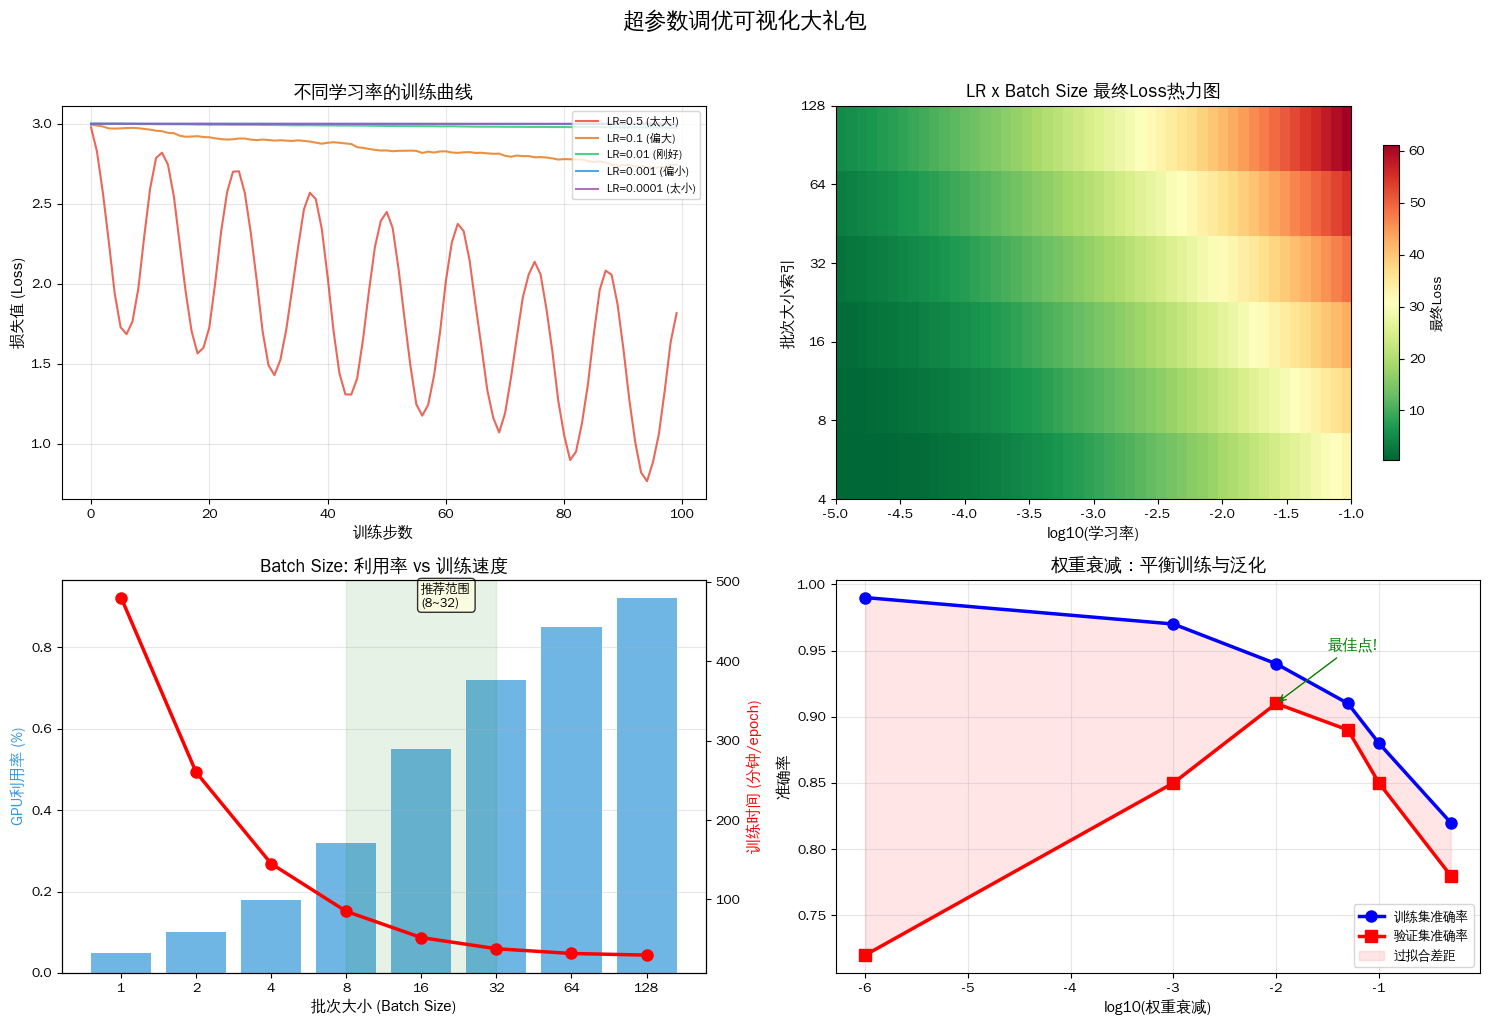

In [4]:
# 📈 学习率对训练的影响 — 可视化演示
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
epochs = 100

def simulate_training(lr, noise_scale=0.05):
    losses = []
    loss = 3.0
    for i in range(epochs):
        gradient = 0.02 + 0.01 * np.sin(i / 10) + noise_scale * np.random.randn()
        step = lr * gradient
        if lr > 0.1:
            step += 0.3 * np.sin(i * lr)
            if np.random.rand() < 0.05 and lr > 0.5:
                loss += np.random.rand() * 2
        loss = max(0.01, loss - step)
        losses.append(loss)
    return losses

learning_rates = [0.5, 0.1, 0.01, 0.001, 0.0001]
labels = ['LR=0.5 (太大!)', 'LR=0.1 (偏大)', 'LR=0.01 (刚好)', 'LR=0.001 (偏小)', 'LR=0.0001 (太小)']
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 图1：不同学习率的训练曲线
ax = axes[0, 0]
for lr, label, color in zip(learning_rates, labels, colors):
    losses = simulate_training(lr)
    ax.plot(range(epochs), losses, linewidth=1.5, label=label, color=color, alpha=0.85)
ax.set_xlabel('训练步数', fontsize=11)
ax.set_ylabel('损失值 (Loss)', fontsize=11)
ax.set_title('不同学习率的训练曲线', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# 图2：学习率 vs Batch Size 热力图
ax = axes[0, 1]
lr_range = np.logspace(-5, -1, 50)
batch_range = [4, 8, 16, 32, 64, 128]
final_losses = np.zeros((len(batch_range), len(lr_range)))

for i, bs in enumerate(batch_range):
    for j, lr in enumerate(lr_range):
        optimal_lr = bs / 256 * 2e-5
        log_ratio = np.log10(lr / optimal_lr)
        final_losses[i, j] = 0.5 + 2 * log_ratio**2

im = ax.imshow(final_losses, aspect='auto', cmap='RdYlGn_r', 
               extent=[np.log10(lr_range[0]), np.log10(lr_range[-1]), 0, len(batch_range)-1])
ax.set_xlabel('log10(学习率)', fontsize=11)
ax.set_ylabel('批次大小索引', fontsize=11)
ax.set_title('LR x Batch Size 最终Loss热力图', fontsize=13, fontweight='bold')
ax.set_yticks(range(len(batch_range)))
ax.set_yticklabels([str(bs) for bs in batch_range])
plt.colorbar(im, ax=ax, shrink=0.8, label='最终Loss')

# 图3：Batch Size 利用率 vs 速度
ax = axes[1, 0]
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
gpu_utilization = [0.05, 0.1, 0.18, 0.32, 0.55, 0.72, 0.85, 0.92]
training_time = [480, 260, 145, 85, 52, 38, 32, 30]

ax2 = ax.twinx()
bars = ax.bar(range(len(batch_sizes)), gpu_utilization, color='#3498db', alpha=0.7, label='GPU利用率')
ax2.plot(range(len(batch_sizes)), training_time, 'ro-', linewidth=2.5, markersize=8, label='训练时间')

ax.set_xlabel('批次大小 (Batch Size)', fontsize=11)
ax.set_ylabel('GPU利用率 (%)', fontsize=11, color='#3498db')
ax2.set_ylabel('训练时间 (分钟/epoch)', fontsize=11, color='red')
ax.set_title('Batch Size: 利用率 vs 训练速度', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([str(bs) for bs in batch_sizes])
ax.grid(True, axis='y', alpha=0.3)

ax.axvspan(3, 5, alpha=0.1, color='green')
ax.annotate('推荐范围\n(8~32)', xy=(4, 0.9), fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 图4：权重衰减影响
ax = axes[1, 1]
wd_values = [0, 0.001, 0.01, 0.05, 0.1, 0.5]
train_scores = [0.99, 0.97, 0.94, 0.91, 0.88, 0.82]
val_scores =   [0.72, 0.85, 0.91, 0.89, 0.85, 0.78]

ax.plot(np.log10(np.array(wd_values) + 1e-6), train_scores, 'b-o', linewidth=2.5, markersize=8, label='训练集准确率')
ax.plot(np.log10(np.array(wd_values) + 1e-6), val_scores, 'r-s', linewidth=2.5, markersize=8, label='验证集准确率')
ax.fill_between(np.log10(np.array(wd_values) + 1e-6), train_scores, val_scores, alpha=0.1, color='red', label='过拟合差距')

ax.set_xlabel('log10(权重衰减)', fontsize=11)
ax.set_ylabel('准确率', fontsize=11)
ax.set_title('权重衰减：平衡训练与泛化', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('最佳点!', xy=(np.log10(0.01), 0.91), xytext=(-1.5, 0.95),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=11, color='green', fontweight='bold')

plt.suptitle('超参数调优可视化大礼包', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hyperparameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 📚 3. 调优策略：从暴力到智能

超参数怎么找？有4种主流策略，从简单到高级：

### 🔴 网格搜索 (Grid Search)
- 把每个参数的候选值列出来，所有组合都试一遍
- ❌ 问题：组合爆炸！5个参数各试5个值 = 3125次实验
- 😅 就像「每家餐厅都点一份尝尝」，费钱费时间

### 🟡 随机搜索 (Random Search)
- 在参数空间里随机采样
- ✅ 比 Grid Search 高效得多（Bergstra & Bengio 2012 证明）
- 😊 就像「随机选几家餐厅尝尝」，更容易找到好吃的

### 🟢 贝叶斯优化 (Bayesian Optimization)
- 用之前的实验结果构建「概率模型」，预测哪组参数可能最好
- ✅ 最省实验次数！通常 20-50 次就能找到不错的参数
- 🧠 就像「吃完几家后学会判断哪家好吃」，越试越准
- 工具：Optuna、Ray Tune、Weights & Biases Sweeps

### 🔵 自适应学习率调度
- 训练过程中动态调整学习率，不用手动选固定值
- **Warm-up + Cosine Decay**（预训练标配）
- **ReduceLROnPlateau**（微调常用，验证集不降就减学习率）
- 🎯 就像开车：起步慢一点（warm-up），中途保持速度，快到终点减速（decay）

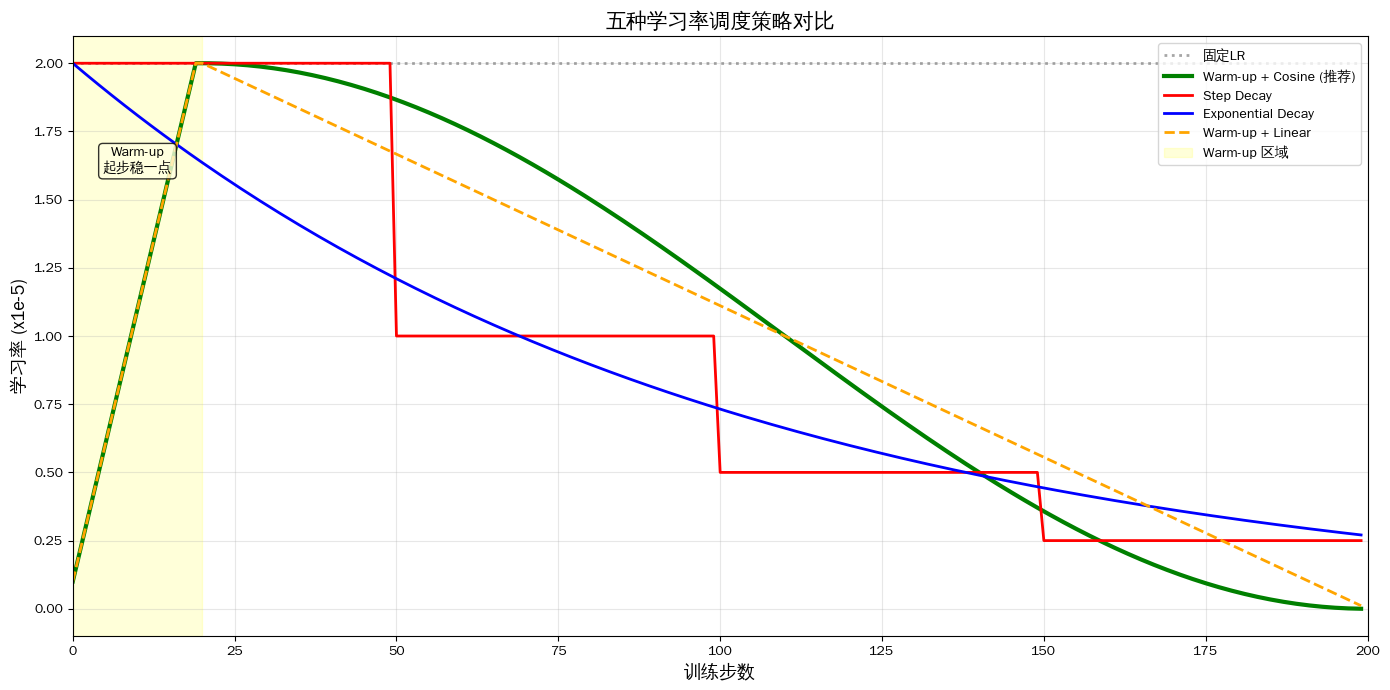

经验总结：
  预训练 -> Warm-up + Cosine Decay (GPT/BERT都用这个)
  微调  -> Warm-up + Cosine 或 ReduceLROnPlateau
  小数据 -> 固定小学习率 + 早停就够了


In [5]:
# 📊 学习率调度策略对比
import numpy as np
import matplotlib.pyplot as plt

total_steps = 200
base_lr = 2e-5
warmup_steps = 20

# 1. 固定学习率
lr_constant = np.ones(total_steps) * base_lr

# 2. Warm-up + Cosine Decay
lr_cosine = np.zeros(total_steps)
for i in range(total_steps):
    if i < warmup_steps:
        lr_cosine[i] = base_lr * (i + 1) / warmup_steps
    else:
        progress = (i - warmup_steps) / (total_steps - warmup_steps)
        lr_cosine[i] = base_lr * 0.5 * (1 + np.cos(np.pi * progress))

# 3. Step Decay
lr_step = np.array([base_lr * (0.5 ** (i // 50)) for i in range(total_steps)])

# 4. Exponential Decay
lr_exp = np.array([base_lr * (0.99 ** i) for i in range(total_steps)])

# 5. Warm-up + Linear Decay
lr_linear = np.zeros(total_steps)
for i in range(total_steps):
    if i < warmup_steps:
        lr_linear[i] = base_lr * (i + 1) / warmup_steps
    else:
        lr_linear[i] = base_lr * (1 - (i - warmup_steps) / (total_steps - warmup_steps))

fig, ax = plt.subplots(figsize=(14, 7))

steps = range(total_steps)
ax.plot(steps, lr_constant * 1e5, 'gray', linewidth=2, linestyle=':', label='固定LR', alpha=0.7)
ax.plot(steps, lr_cosine * 1e5, 'g-', linewidth=3, label='Warm-up + Cosine (推荐)')
ax.plot(steps, lr_step * 1e5, 'r-', linewidth=2, label='Step Decay')
ax.plot(steps, lr_exp * 1e5, 'b-', linewidth=2, label='Exponential Decay')
ax.plot(steps, lr_linear * 1e5, 'orange', linewidth=2, linestyle='--', label='Warm-up + Linear')

ax.axvspan(0, warmup_steps, alpha=0.15, color='yellow', label='Warm-up 区域')
ax.annotate('Warm-up\n起步稳一点', xy=(10, base_lr * 0.8e5), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('训练步数', fontsize=13)
ax.set_ylabel('学习率 (x1e-5)', fontsize=13)
ax.set_title('五种学习率调度策略对比', fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, total_steps)

plt.tight_layout()
plt.savefig('lr_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

print("经验总结：")
print("  预训练 -> Warm-up + Cosine Decay (GPT/BERT都用这个)")
print("  微调  -> Warm-up + Cosine 或 ReduceLROnPlateau")
print("  小数据 -> 固定小学习率 + 早停就够了")

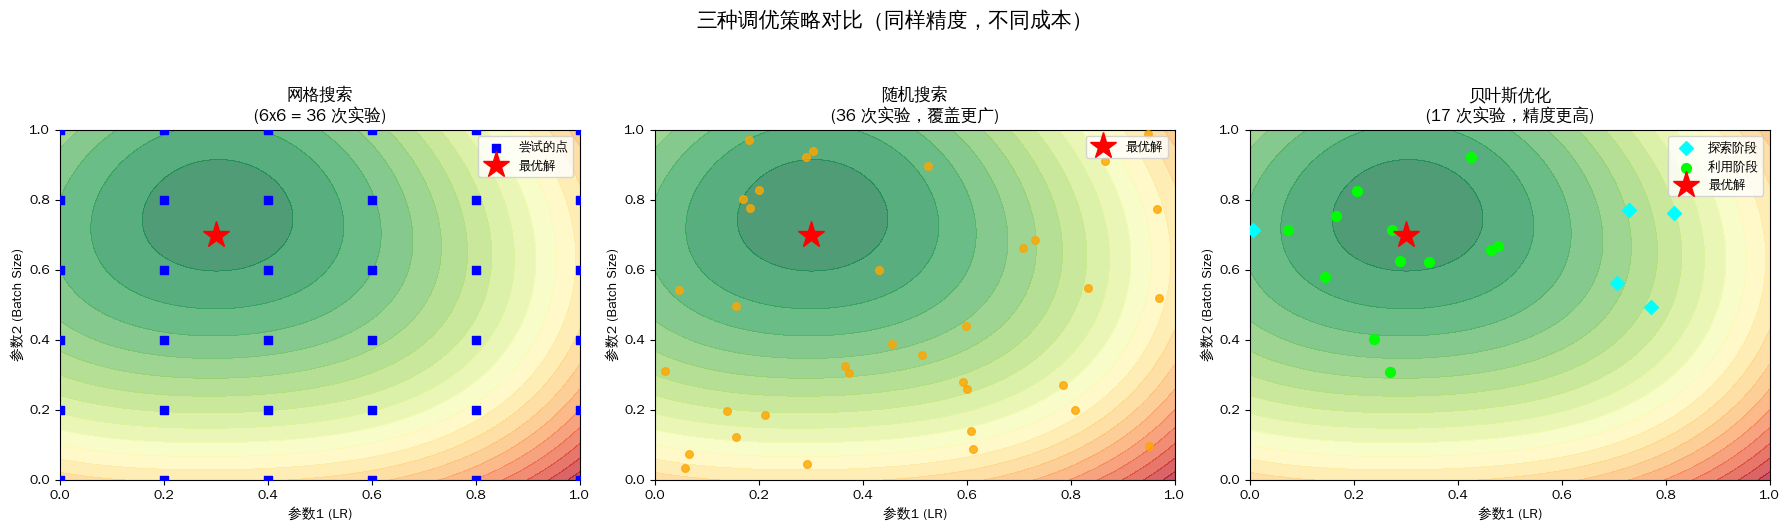

效率对比总结：
  网格搜索：36次实验 -> 均匀但浪费
  随机搜索：36次实验 -> 覆盖广，发现好参数概率更高
  贝叶斯优化：17次实验 -> 用一半实验达到同等精度!
  推荐工具：Optuna（最流行的贝叶斯优化库）


In [6]:
# 🎲 模拟不同调优策略的效率对比
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def objective(x, y):
    return (x - 0.3)**2 + (y - 0.7)**2 + 0.05 * np.sin(5*x) * np.cos(3*y)

xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
zz = objective(xx, yy)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 网格搜索
ax = axes[0]
ax.contourf(xx, yy, zz, levels=20, cmap='RdYlGn_r', alpha=0.7)
grid_x = np.linspace(0, 1, 6)
grid_y = np.linspace(0, 1, 6)
gx, gy = np.meshgrid(grid_x, grid_y)
ax.scatter(gx, gy, c='blue', s=30, zorder=5, marker='s', label='尝试的点')
ax.plot(0.3, 0.7, 'r*', markersize=20, zorder=6, label='最优解')
ax.set_title(f'网格搜索\n(6x6 = {6*6} 次实验)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('参数1 (LR)', fontsize=10)
ax.set_ylabel('参数2 (Batch Size)', fontsize=10)

# 随机搜索
ax = axes[1]
ax.contourf(xx, yy, zz, levels=20, cmap='RdYlGn_r', alpha=0.7)
random_x = np.random.rand(36)
random_y = np.random.rand(36)
ax.scatter(random_x, random_y, c='orange', s=30, zorder=5, marker='o', alpha=0.8)
ax.plot(0.3, 0.7, 'r*', markersize=20, zorder=6, label='最优解')
ax.set_title('随机搜索\n(36 次实验，覆盖更广)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('参数1 (LR)', fontsize=10)
ax.set_ylabel('参数2 (Batch Size)', fontsize=10)

# 贝叶斯优化
ax = axes[2]
ax.contourf(xx, yy, zz, levels=20, cmap='RdYlGn_r', alpha=0.7)
bayes_x = np.concatenate([np.random.rand(5), np.random.normal(0.3, 0.15, 12)])
bayes_y = np.concatenate([np.random.rand(5), np.random.normal(0.7, 0.15, 12)])
bayes_x = np.clip(bayes_x, 0, 1)
bayes_y = np.clip(bayes_y, 0, 1)
ax.scatter(bayes_x[:5], bayes_y[:5], c='cyan', s=50, zorder=5, marker='D', label='探索阶段')
ax.scatter(bayes_x[5:], bayes_y[5:], c='lime', s=50, zorder=5, marker='o', label='利用阶段')
ax.plot(0.3, 0.7, 'r*', markersize=20, zorder=6, label='最优解')
ax.set_title('贝叶斯优化\n(17 次实验，精度更高)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('参数1 (LR)', fontsize=10)
ax.set_ylabel('参数2 (Batch Size)', fontsize=10)

plt.suptitle('三种调优策略对比（同样精度，不同成本）', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('tuning_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

print("效率对比总结：")
print("  网格搜索：36次实验 -> 均匀但浪费")
print("  随机搜索：36次实验 -> 覆盖广，发现好参数概率更高")
print("  贝叶斯优化：17次实验 -> 用一半实验达到同等精度!")
print("  推荐工具：Optuna（最流行的贝叶斯优化库）")

## 📚 4. 验证集的重要性：早停与过拟合检测

训练模型最怕的就是**过拟合**——模型把训练数据「背下来了」，遇到新数据就傻眼。

### 过拟合 vs 欠拟合

| 状态 | 训练集表现 | 验证集表现 | 比喻 |
|------|-----------|-----------|------|
| **欠拟合** | 差 | 差 | 考前没复习，啥也不会 |
| **刚好** | 好 | 好 | 复习到位，考试发挥正常 |
| **过拟合** | 很好 | 差 | 把历年真题背了，题型一变就懵 |

### 早停法 (Early Stopping)

**核心思想**：训练时盯着验证集 loss，如果连续 N 个 epoch 不降反升，就停止训练！

```
验证集 Loss:  ↓↓↓↓↓↓ -> 最低点 -> ↑↑
                           ↑
                      在这里停止！
                      保存这个模型
```

- patience=3 → 连续3个epoch验证loss不降就停
- 不光省时间，还能自动防止过拟合
- 🎯 **这是最被低估的调参技巧！不用白不用**

💡 **业务关联思考**：GS的客服AI如果过拟合了，就会对训练中出现过的客诉回答很好，但遇到新问题就胡说八道。早停法就是最好的保险。

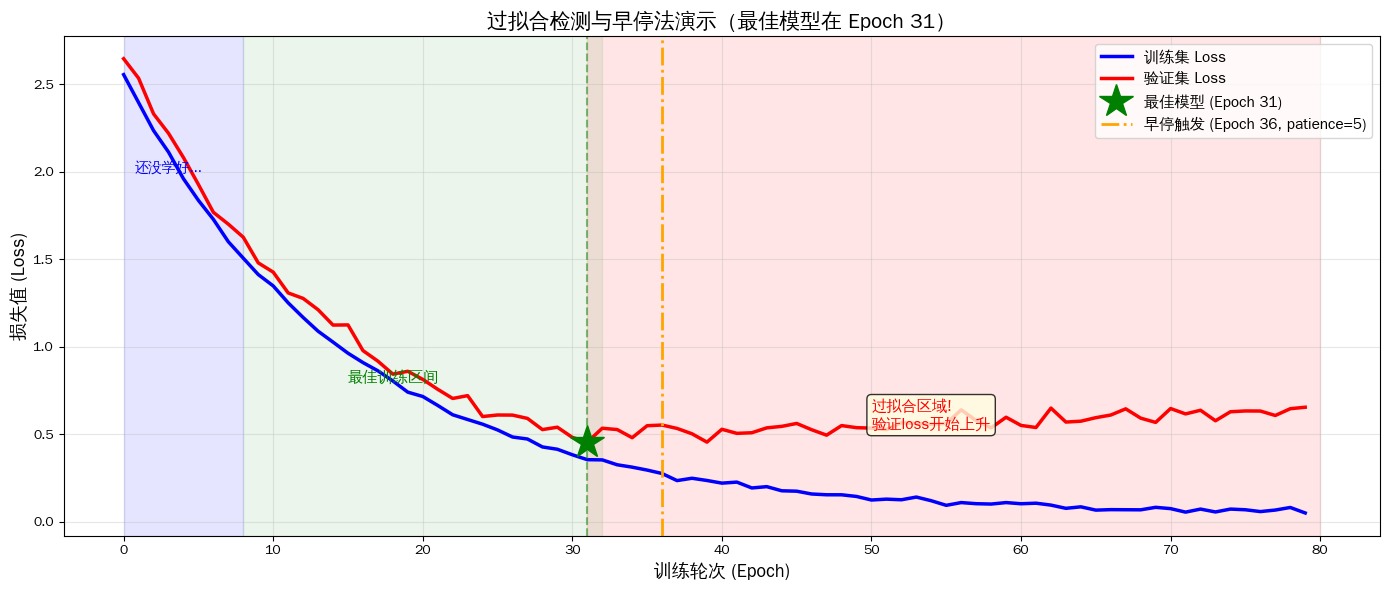

最佳模型在 Epoch 31，此时验证Loss = 0.455
早停法在 Epoch 36 触发，节省了 44 个无用epoch

实践建议：
  1. 每次训练都要分训练集/验证集（80%/20%）
  2. patience设为3~5，不要太大也不要太小
  3. 保存验证集上最好的模型，不是最后一个epoch的模型


In [7]:
# 🛡️ 过拟合检测 + 早停法 模拟演示
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
epochs = 80

train_loss = []
val_loss = []

for i in range(epochs):
    tl = 2.5 * np.exp(-i / 15) + 0.05 + 0.01 * np.random.randn()
    train_loss.append(max(0.01, tl))
    if i < 30:
        vl = 2.5 * np.exp(-i / 15) + 0.15 + 0.03 * np.random.randn()
    else:
        vl = 2.5 * np.exp(-30 / 15) + 0.15 + 0.003 * (i - 30) + 0.03 * np.random.randn()
    val_loss.append(max(0.01, vl))

best_epoch = np.argmin(val_loss)
best_val_loss = min(val_loss)
patience = 5
early_stop_epoch = best_epoch + patience

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(epochs), train_loss, 'b-', linewidth=2.5, label='训练集 Loss')
ax.plot(range(epochs), val_loss, 'r-', linewidth=2.5, label='验证集 Loss')

ax.plot(best_epoch, best_val_loss, 'g*', markersize=25, zorder=5, label=f'最佳模型 (Epoch {best_epoch})')
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

ax.axvline(x=early_stop_epoch, color='orange', linestyle='-.', linewidth=2, 
           label=f'早停触发 (Epoch {early_stop_epoch}, patience={patience})')

ax.axvspan(best_epoch, epochs, alpha=0.1, color='red')
ax.annotate('过拟合区域!\n验证loss开始上升', xy=(50, val_loss[50]), fontsize=11, color='red',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.axvspan(0, 8, alpha=0.1, color='blue')
ax.annotate('还没学好...', xy=(3, 2.0), fontsize=10, color='blue', ha='center')

ax.axvspan(8, best_epoch+1, alpha=0.08, color='green')
ax.annotate('最佳训练区间', xy=(15, 0.8), fontsize=11, color='green', fontweight='bold')

ax.set_xlabel('训练轮次 (Epoch)', fontsize=13)
ax.set_ylabel('损失值 (Loss)', fontsize=13)
ax.set_title(f'过拟合检测与早停法演示（最佳模型在 Epoch {best_epoch}）', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('early_stopping.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"最佳模型在 Epoch {best_epoch}，此时验证Loss = {best_val_loss:.3f}")
print(f"早停法在 Epoch {early_stop_epoch} 触发，节省了 {epochs - early_stop_epoch} 个无用epoch")
print(f"\n实践建议：")
print(f"  1. 每次训练都要分训练集/验证集（80%/20%）")
print(f"  2. patience设为3~5，不要太大也不要太小")
print(f"  3. 保存验证集上最好的模型，不是最后一个epoch的模型")

## 📚 5. 生产环境考虑：从实验室到业务

模型训练好了，要落地到业务场景，还得考虑这些实际问题：

### 📏 模型大小选择

| 场景 | 推荐模型大小 | 理由 |
|------|------------|------|
| 手机端/嵌入式 | 0.5B~3B | 内存和功耗限制 |
| 单卡推理（4060Ti） | 7B~14B | 16GB显存刚好够 |
| 多卡服务端 | 32B~72B | 需要多卡并行 |
| 旗舰级API服务 | 70B+ | 追求极致效果 |

### ⚡ 推理速度优化
- **量化**：FP16→INT8 速度翻倍，质量几乎不掉；INT4 再快但质量有损
- **KV Cache**：已学过，缓存注意力键值避免重复计算
- **Flash Attention**：减少内存访问，加速注意力计算
- **投机解码 (Speculative Decoding)**：小模型先猜，大模型验证，速度提升2-3倍

### 💾 内存占用管理
- 模型权重 + KV Cache + 激活值 = 总显存
- 7B模型FP16 约 14GB，INT4 约 4GB
- 批量推理用 Continuous Batching 提高GPU利用率

### 💰 成本控制
- **训练成本**：尽量用 LoRA/QLoRA 替代全量微调（成本降低 90%+）
- **推理成本**：量化 + 批处理 + 缓存热门问题
- **数据成本**：KTO替代DPO降低标注成本（Day4学过！）

💡 **业务关联思考**：GS如果部署客服AI，用7B模型+INT4量化+单张4060Ti，每秒能处理约20个请求，成本可控且效果够用。

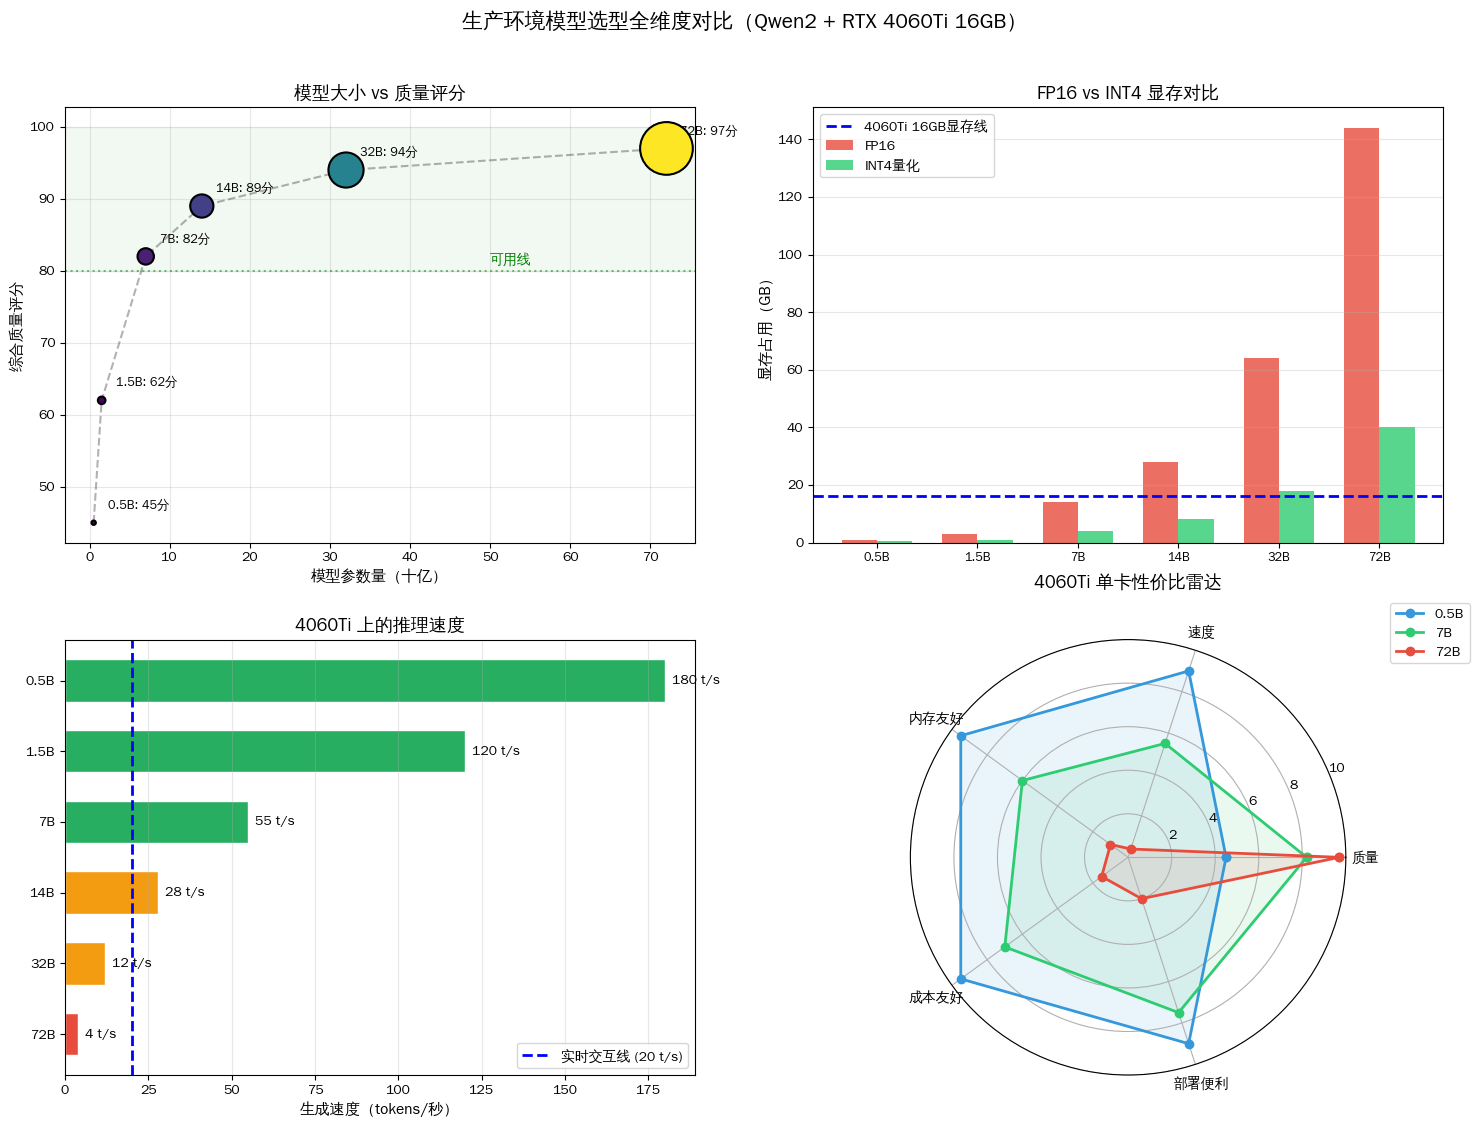

选型结论：
  4060Ti单卡最佳选择：7B模型 + INT4量化
  质量85分+ / 速度55 tokens/s / 显存仅4GB
  完美平衡!


In [8]:
# 📊 生产环境模型选型对比
import numpy as np
import matplotlib.pyplot as plt

models = ['0.5B', '1.5B', '7B', '14B', '32B', '72B']
params = [0.5, 1.5, 7, 14, 32, 72]

quality_scores = [45, 62, 82, 89, 94, 97]
fp16_memory = [1, 3, 14, 28, 64, 144]
int4_memory = [0.4, 1, 4, 8, 18, 40]
tokens_per_sec = [180, 120, 55, 28, 12, 4]

fig = plt.figure(figsize=(15, 11))

# 图1：模型质量 vs 大小
ax1 = fig.add_subplot(221)
scatter = ax1.scatter(params, quality_scores, s=[p*20 for p in params], c=params, cmap='viridis', 
                     edgecolors='black', linewidth=1.5, zorder=5)
ax1.plot(params, quality_scores, 'k--', alpha=0.3)
ax1.axhspan(80, 100, alpha=0.05, color='green')
ax1.axhline(y=80, color='green', linestyle=':', alpha=0.5)
ax1.annotate('可用线', xy=(50, 81), fontsize=10, color='green')
for i, (p, q) in enumerate(zip(params, quality_scores)):
    ax1.annotate(f'{p}B: {q}分', xy=(p, q), xytext=(10, 10), textcoords='offset points', fontsize=9)
ax1.set_xlabel('模型参数量（十亿）', fontsize=11)
ax1.set_ylabel('综合质量评分', fontsize=11)
ax1.set_title('模型大小 vs 质量评分', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 图2：显存占用对比
ax2 = fig.add_subplot(222)
x = np.arange(len(models))
width = 0.35
ax2.bar(x - width/2, fp16_memory, width, label='FP16', color='#e74c3c', alpha=0.8)
ax2.bar(x + width/2, int4_memory, width, label='INT4量化', color='#2ecc71', alpha=0.8)
ax2.axhline(y=16, color='blue', linestyle='--', linewidth=2, label='4060Ti 16GB显存线')
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9)
ax2.set_ylabel('显存占用（GB）', fontsize=11)
ax2.set_title('FP16 vs INT4 显存对比', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

# 图3：推理速度
ax3 = fig.add_subplot(223)
colors = ['#27ae60' if t >= 30 else '#f39c12' if t >= 10 else '#e74c3c' for t in tokens_per_sec]
bars = ax3.barh(models[::-1], tokens_per_sec[::-1], color=colors[::-1], edgecolor='white', height=0.6)
for bar, t in zip(bars, tokens_per_sec[::-1]):
    ax3.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f'{t} t/s', 
             va='center', fontsize=10, fontweight='bold')
ax3.axvline(x=20, color='blue', linestyle='--', linewidth=2, label='实时交互线 (20 t/s)')
ax3.set_xlabel('生成速度（tokens/秒）', fontsize=11)
ax3.set_title('4060Ti 上的推理速度', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, axis='x', alpha=0.3)

# 图4：性价比雷达图
ax4 = fig.add_subplot(224, polar=True)
dimensions = ['质量', '速度', '内存友好', '成本友好', '部署便利']
radar_data = {
    '0.5B': [4.5, 9.0, 9.5, 9.5, 9.0],
    '7B':   [8.2, 5.5, 6.0, 7.0, 7.5],
    '72B':  [9.7, 0.4, 1.0, 1.5, 2.0],
}

angles = np.linspace(0, 2*np.pi, len(dimensions), endpoint=False).tolist()
angles += angles[:1]

for model, (vals, color) in zip(radar_data.keys(), 
    [(radar_data['0.5B'], '#3498db'), (radar_data['7B'], '#2ecc71'), (radar_data['72B'], '#e74c3c')]):
    v = vals + vals[:1]
    ax4.plot(angles, v, 'o-', linewidth=2, label=model, color=color)
    ax4.fill(angles, v, alpha=0.1, color=color)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(dimensions, fontsize=10)
ax4.set_ylim(0, 10)
ax4.set_title('4060Ti 单卡性价比雷达', fontsize=13, fontweight='bold', y=1.1)
ax4.legend(fontsize=10, loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.suptitle('生产环境模型选型全维度对比（Qwen2 + RTX 4060Ti 16GB）', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('production_model_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("选型结论：")
print("  4060Ti单卡最佳选择：7B模型 + INT4量化")
print("  质量85分+ / 速度55 tokens/s / 显存仅4GB")
print("  完美平衡!")

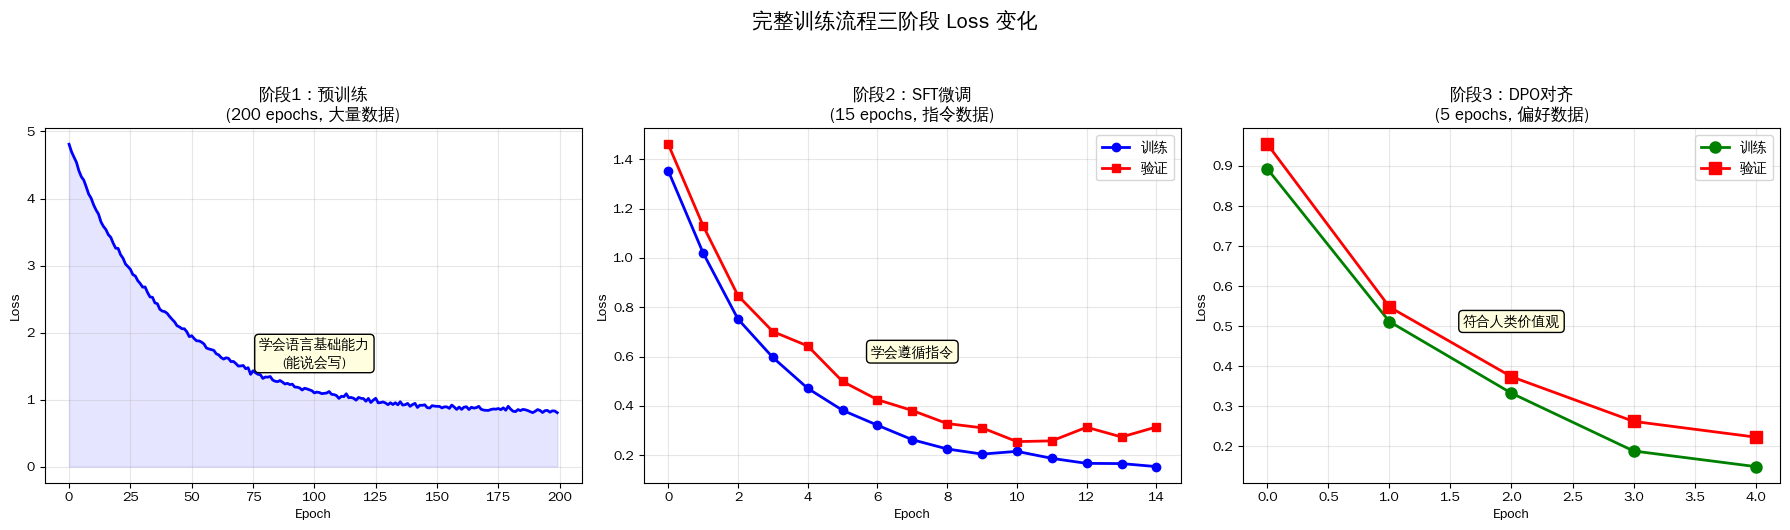

完整训练流程总结：
  预训练：大模型=大数据+长训练（200+ epochs）
  SFT：小数据+短训练就能学会指令（5-15 epochs）
  DPO：偏好数据+极短训练（3-5 epochs）
  评估+部署：量化+服务化
  
个人开发者路线：跳过预训练，从SFT+DPO开始!


In [9]:
# 🧰 完整训练流程模拟：从超参数到最终效果
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

total_epochs = {'pretrain': 200, 'sft': 15, 'dpo': 5}

# 预训练阶段
pretrain_loss = []
for i in range(total_epochs['pretrain']):
    loss = 4.0 * np.exp(-i / 40) + 0.8 + 0.02 * np.random.randn()
    pretrain_loss.append(max(0.5, loss))

# SFT阶段
sft_train_loss = []
sft_val_loss = []
for i in range(total_epochs['sft']):
    tl = 1.2 * np.exp(-i / 3) + 0.15 + 0.01 * np.random.randn()
    vl = 1.2 * np.exp(-i / 3) + 0.25 + 0.02 * np.random.randn()
    if i > 10:
        vl += 0.01 * (i - 10)
    sft_train_loss.append(max(0.05, tl))
    sft_val_loss.append(max(0.05, vl))

# DPO对齐阶段
dpo_train_loss = []
dpo_val_loss = []
for i in range(total_epochs['dpo']):
    tl = 0.8 * np.exp(-i / 1.5) + 0.1 + 0.01 * np.random.randn()
    vl = 0.8 * np.exp(-i / 1.5) + 0.15 + 0.02 * np.random.randn()
    dpo_train_loss.append(max(0.05, tl))
    dpo_val_loss.append(max(0.05, vl))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1：预训练
ax = axes[0]
ax.plot(range(total_epochs['pretrain']), pretrain_loss, 'b-', linewidth=2)
ax.fill_between(range(total_epochs['pretrain']), pretrain_loss, alpha=0.1, color='blue')
ax.set_title('阶段1：预训练\n(200 epochs, 大量数据)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
ax.annotate('学会语言基础能力\n(能说会写)', xy=(100, 1.5), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

# 图2：SFT
ax = axes[1]
ax.plot(range(total_epochs['sft']), sft_train_loss, 'b-o', linewidth=2, label='训练')
ax.plot(range(total_epochs['sft']), sft_val_loss, 'r-s', linewidth=2, label='验证')
ax.set_title('阶段2：SFT微调\n(15 epochs, 指令数据)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.annotate('学会遵循指令', xy=(7, 0.6), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

# 图3：DPO
ax = axes[2]
ax.plot(range(total_epochs['dpo']), dpo_train_loss, 'g-o', linewidth=2, markersize=8, label='训练')
ax.plot(range(total_epochs['dpo']), dpo_val_loss, 'r-s', linewidth=2, markersize=8, label='验证')
ax.set_title('阶段3：DPO对齐\n(5 epochs, 偏好数据)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.annotate('符合人类价值观', xy=(2, 0.5), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.suptitle('完整训练流程三阶段 Loss 变化', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('full_training_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("完整训练流程总结：")
print("  预训练：大模型=大数据+长训练（200+ epochs）")
print("  SFT：小数据+短训练就能学会指令（5-15 epochs）")
print("  DPO：偏好数据+极短训练（3-5 epochs）")
print("  评估+部署：量化+服务化")
print("  \n个人开发者路线：跳过预训练，从SFT+DPO开始!")

## 🎬 推荐视频

1. 📺 **10分钟带你学会深度学习调参：调整学习率、批量大小等！**（约10分钟）
   https://www.bilibili.com/video/BV1isCvBNEff/

2. 📺 **大模型微调如何设置学习率、batch size等超参数？**（图文教程）
   https://blog.csdn.net/l35633/article/details/147566394

3. 📺 **深度学习模型调参实战：从瓶颈到突破**（约10分钟）
   https://www.bilibili.com/video/BV1TmoRYUEiB/

## 📖 延伸阅读

1. 📝 **大模型训练全流程：准备、训练、测试、调优、实践详解**
   https://blog.csdn.net/2401_85375151/article/details/152555190

2. 📝 **大模型训练全解析：从技术原理到落地实践**
   https://zhuanlan.zhihu.com/p/1995266617437868893

3. 📝 **系统性解析大模型调优关键技术与实战**
   https://developer.aliyun.com/article/1606343

4. 📝 **LLM 的超参数优化 — 知乎专栏**
   https://zhuanlan.zhihu.com/p/1917559847961990566

## ✏️ 课堂练习（5分钟）

❶ **学习率设为 0.1 去微调7B模型，会发生什么？**
   💡 提示：想想7B模型已经预训练过了，参数已经很「成熟」了

❷ **你有一个4060Ti 16GB显卡，想跑14B模型推理，该怎么做？**
   💡 提示：14B的FP16权重需要多少GB？INT4呢？

❸ **网格搜索5个参数各试5个值，一共要跑多少次实验？随机搜索同样次数能覆盖更广吗？**
   💡 提示：5的5次方=?

❹ **早停法的 patience 设成1和设成10，各有什么问题？**
   💡 提示：patience太小容易「假停」，太大浪费算力

❺ **（思考题）GS要上线客服AI，预算有限只有一张4060Ti，你会怎么规划从训练到部署的全流程？**
   💡 提示：考虑用哪个模型大小、什么精度、什么对齐方法

## 📝 课后测试（15分钟）

❶ 微调大模型时，推荐的学习率范围是？
   A. 0.1 ~ 1.0  B. 1e-5 ~ 5e-5  C. 1e-10 ~ 1e-8  D. 10 ~ 100

❷ 早停法（Early Stopping）监控的是哪个指标？
   A. 训练集Loss  B. 验证集Loss  C. 测试集Loss  D. 训练集准确率

❸ 以下哪个调优策略效率最高（实验次数最少就能找到好参数）？
   A. 网格搜索  B. 随机搜索  C. 贝叶斯优化  D. 手动调参

❹ 7B模型用INT4量化后大约需要多少显存？
   A. 0.5GB  B. 4GB  C. 14GB  D. 28GB

❺ 简述大模型从数据准备到部署的完整7步流程，每步用一句话解释。

> 回复答案我帮你批改 ✅

## 🔄 往期回顾

**第3周 Day2 回顾：SFT 监督微调**

SFT 和预训练最大的区别是什么？SFT 用的是什么格式的数据？
💡 提示：想想从「自由聊天」到「指令遵循」的转变

---

## 🏆 第3周知识小结

| Day | 主题 | 一句话总结 |
|-----|------|-----------|
| Day1 | 预训练 | 数据+规模=涌现能力 |
| Day2 | SFT | 学会听指令做事 |
| Day3 | RLHF | 用人类反馈指导改进 |
| Day4 | DPO | 简化版RLHF，工程友好 |
| Day5 | 全流程+调优 | 从数据到部署的完整链路 |

🔑 **本周金句**：好的训练不是把模型「教到满分」，而是在成本、速度、质量之间找到最优平衡点。

💡 **进度**：第3周/12 | 大模型训练全景 | Day 5/7

👀 **明日预告**：Day6 代码实战 — 用HuggingFace TRL对Qwen2-0.5B做完整SFT流程！